In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
from sklearn.cluster import KMeans

LUCÍA RIVERO RODRÍGUEZ


BELÉN RIVERO RODRÍGUEZ


In [3]:
data=pd.read_csv("/content/hospital_readmission_dataset.csv")
data.head()

,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
0,P00001,2022-04-14,Spring,66,Male,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,0.92,1
1,P00002,2021-09-19,Fall,55,Male,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,0.88,1
2,P00003,2023-04-12,Spring,69,Female,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,0.97,1
3,P00004,2023-08-14,Summer,83,Male,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,0.97,1
4,P00005,2021-11-05,Fall,54,Female,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,0.83,1


Tenemos un dataset que contiene información detallada sobre pacientes hospitalarios ingresados. Nuestro objetivo será identificar distintos perfiles de pacientes hospitalarios mediante el Clustering.

En primer lugar realizaremos un preprocesamiento de los datos. Para ello vamos a eliminar variables que no nos aporten información para nuestro análisis, en este caso se han elegido: el id del paciente, la fecha de admisión, la estación de admisión, la región y la columna de label, que nos indica si finalmente un paciente reingresa o no.

En este caso, no hace falta preocuparse por datos faltante, ya que no existen en nuestro dataset


In [4]:

# Eliminamos ID, fecha y estación por ser ruido/identificadores
# Eliminamos 'label' para que el clustering sea puramente descriptivo
cols_to_drop = ['patient_id', 'admission_date', 'season', 'region', 'label']
df_clustering = data.drop(columns=cols_to_drop)
df_clustering.head()
# Verificar datos faltantes
print(df_clustering.isnull().sum())

age                          0
gender                       0
primary_diagnosis            0
comorbidities_count          0
length_of_stay               0
treatment_type               0
medications_count            0
followup_visits_last_year    0
prev_readmissions            0
insurance_type               0
discharge_disposition        0
readmission_risk_score       0
dtype: int64


Como sabemos que el clustering se basa en el cálculo de la distancia entre puntos, necesitaremos que todas las variables con las que trabajamos sean numéricas, así que ahora procedemos a la codificación de las variables categóricas. Lo haremos aplicando One-Hot Encoding a estas variables.
Esta técnica crea una nueva columna por cada categoría, y marca con 1 la columna que corresponde al valor original y con un 0 las demás.



In [5]:
df_final = pd.get_dummies(df_clustering, columns=[
    'gender',
    'primary_diagnosis',
    'treatment_type',
    'insurance_type',
    'discharge_disposition'
], drop_first=False, dtype=int)

df_final.head()




,age,comorbidities_count,length_of_stay,medications_count,followup_visits_last_year,prev_readmissions,readmission_risk_score,gender_Female,gender_Male,primary_diagnosis_Appendicitis,...,treatment_type_Medical,treatment_type_Surgical,insurance_type_Medicaid,insurance_type_Medicare,insurance_type_Private,insurance_type_Uninsured,discharge_disposition_Home,discharge_disposition_Home Health,discharge_disposition_Rehab,discharge_disposition_Skilled Nursing
0,66,5,6,8,6,1,0.92,0,1,0,...,0,0,0,1,0,0,0,1,0,0
1,55,4,6,6,4,3,0.88,0,1,0,...,0,0,0,0,1,0,0,1,0,0
2,69,6,8,9,6,2,0.97,1,0,0,...,1,0,0,1,0,0,0,0,0,1
3,83,6,11,11,4,2,0.97,0,1,0,...,1,0,0,1,0,0,0,0,0,1
4,54,4,10,6,2,1,0.83,1,0,0,...,1,0,0,0,0,1,0,1,0,0


Como las variables que tenemos estan medidas en escalas muy diferentes, procedemos a estandarizarlas para que aquellas con mayor valor no "pisen" en el análisis a aquellas con menor valor

In [6]:
from sklearn.preprocessing import StandardScaler

# 1. Inicializar el escalador
scaler = StandardScaler()

# 2. Ajustar y transformar los datos
# Esto convierte todos los valores para que tengan media 0 y varianza 1
data_scaled = scaler.fit_transform(df_final)

df_scaled = pd.DataFrame(data_scaled, columns=df_final.columns)

df_scaled.head()

,age,comorbidities_count,length_of_stay,medications_count,followup_visits_last_year,prev_readmissions,readmission_risk_score,gender_Female,gender_Male,primary_diagnosis_Appendicitis,...,treatment_type_Medical,treatment_type_Surgical,insurance_type_Medicaid,insurance_type_Medicare,insurance_type_Private,insurance_type_Uninsured,discharge_disposition_Home,discharge_disposition_Home Health,discharge_disposition_Rehab,discharge_disposition_Skilled Nursing
0,0.513556,0.501855,-0.926945,0.229153,1.448725,-0.641885,0.650665,-1.047108,1.047108,-0.26744,...,-0.901796,-0.575041,-0.499609,1.465308,-0.785376,-0.335182,-0.203125,0.564840,-0.079305,-0.493742
1,-0.144207,-0.234543,-0.926945,-0.645059,0.221967,1.600508,0.468740,-1.047108,1.047108,-0.26744,...,-0.901796,-0.575041,-0.499609,-0.682450,1.273276,-0.335182,-0.203125,0.564840,-0.079305,-0.493742
2,0.692946,1.238254,0.109254,0.666259,1.448725,0.479311,0.878070,0.955011,-0.955011,-0.26744,...,1.108898,-0.575041,-0.499609,1.465308,-0.785376,-0.335182,-0.203125,-1.770414,-0.079305,2.025350
3,1.530099,1.238254,1.663553,1.540471,0.221967,0.479311,0.878070,-1.047108,1.047108,-0.26744,...,1.108898,-0.575041,-0.499609,1.465308,-0.785376,-0.335182,-0.203125,-1.770414,-0.079305,2.025350
4,-0.204004,-0.234543,1.145453,-0.645059,-1.004792,-0.641885,0.241334,0.955011,-0.955011,-0.26744,...,1.108898,-0.575041,-0.499609,-0.682450,-0.785376,2.983453,-0.203125,0.564840,-0.079305,-0.493742


Ya tenemos los datos limpios y listos para aplicar los distintos algoritmos. Empezamos aplicando el K-medias.

In [ ]:
wcss=[]
for i in range (1,10):
    kmedias= KMeans(n_clusters=i)
    kmedias.fit(df_scaled)
    wcss.append(kmedias.inertia_)
wcss

[255999.99999999994,
 218820.72097331996,
 209534.55510405815,
 198484.84189647326,
 191228.49006731604,
 187309.46843517228,
 176414.17316715108,
 171820.7595553169,
 164073.16781083838]

Para determinar el número de clusters correspondientes, realizaremos el gráfico del codo

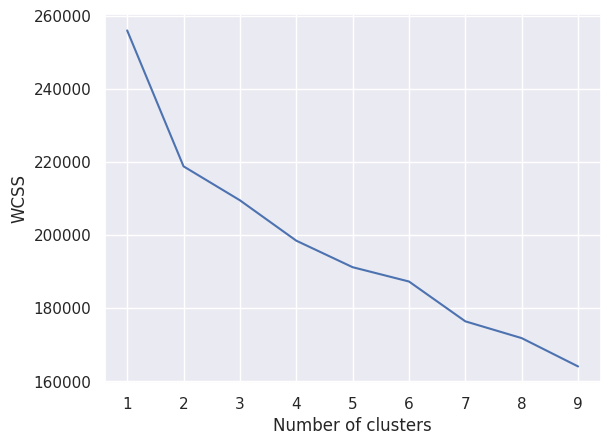

In [ ]:
plt.plot(range(1,10),wcss)
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

Observando el gráfico del codo, vemos un corte en k=2, sin embargo con el objetivo de perder la menor información posible, se ha decidido empezar probando con 5 clusters, e ir disminuyendo hasta 2 para ver que información obtenemos. Para ello analizaremos los centroides de los distintos clusteres.

In [ ]:
from IPython.display import display

traduccion = {
    'age': 'Edad',
    'comorbidities_count': 'Nº comorbilidades',
    'length_of_stay': 'Días de estancia',
    'medications_count': 'Nº medicamentos',
    'followup_visits_last_year': 'Visitas seguimiento (último año)',
    'prev_readmissions': 'Reingresos previos',
    'readmission_risk_score': 'Puntuación de riesgo de reingreso',
    'gender_Male': 'Género (Hombre)',
    'primary_diagnosis_COPD': 'Diagnóstico: EPOC',
    'primary_diagnosis_Appendicitis' : 'Diágonistico de Apendicitis',
    'primary_diagnosis_Diabetes': 'Diagnóstico: Diabetes',
    'primary_diagnosis_Fracture': 'Diagnóstico: Fractura',
    'primary_diagnosis_Heart Failure': 'Diagnóstico: Insuficiencia cardíaca',
    'primary_diagnosis_Hypertension': 'Diagnóstico: Hipertensión',
    'primary_diagnosis_Influenza': 'Diagnóstico: Gripe',
    'primary_diagnosis_Kidney Disease': 'Diagnóstico: Enfermedad renal',
    'primary_diagnosis_Pneumonia': 'Diagnóstico: Neumonía',
    'primary_diagnosis_Sepsis': 'Diagnóstico: Sepsis',
    'primary_diagnosis_Stroke': 'Diagnóstico: Ictus',
    'treatment_type_Interventional': 'Tratamiento: Intervencionista',
    'treatment_type_Medical': 'Tratamiento: Médico',
    'treatment_type_Surgical': 'Tratamiento: Quirúrgico',
    'insurance_type_Medicare': 'Seguro: Medicare',
    'insurance_type_Private': 'Seguro: Privado',
    'insurance_type_Uninsured': 'Sin seguro',
    'discharge_disposition_Home Health': 'Alta: Atención domiciliaria',
    'discharge_disposition_Rehab': 'Alta: Rehabilitación',
    'discharge_disposition_Skilled Nursing': 'Alta: Enfermería especializada'
}

for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_new = df_final.copy()
    cluster_new['cluster_pred'] = km.fit_predict(data_scaled)

    resumen = cluster_new.groupby('cluster_pred').mean().T.round(3)
    resumen.index = resumen.index.map(lambda x: traduccion.get(x, x))

    styled = (resumen.style
        .background_gradient(cmap='RdYlGn', axis=1)
        .format('{:.3f}')
        .set_caption(f'K-Means — k={k}: ADN de Clústeres')
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '15px'), ('font-weight', 'bold'), ('margin-bottom', '8px')]},
            {'selector': 'th',
             'props': [('text-align', 'center'), ('font-size', '13px')]},
            {'selector': 'td',
             'props': [('text-align', 'center'), ('font-size', '12px')]}
        ])
    )

    display(styled)
    print("\n")

cluster_pred,0,1
Edad,48.503,75.056
Nº comorbilidades,3.614,5.715
Días de estancia,7.577,8.209
Nº medicamentos,6.415,9.577
Visitas seguimiento (último año),2.825,5.249
Reingresos previos,1.205,2.300
Puntuación de riesgo de reingreso,0.682,0.965
gender_Female,0.525,0.518
Género (Hombre),0.475,0.482
Diágonistico de Apendicitis,0.063,0.073


cluster_pred,0,1,2
Edad,43.712,77.077,61.135
Nº comorbilidades,3.192,6.377,4.436
Días de estancia,6.748,8.331,8.479
Nº medicamentos,5.696,10.536,7.744
Visitas seguimiento (último año),2.516,5.440,3.862
Reingresos previos,1.036,2.608,1.605
Puntuación de riesgo de reingreso,0.545,0.970,0.899
gender_Female,0.499,0.521,0.545
Género (Hombre),0.501,0.479,0.455
Diágonistico de Apendicitis,0.082,0.075,0.049


cluster_pred,0,1,2,3
Edad,72.051,28.511,49.703,77.077
Nº comorbilidades,4.844,1.813,3.742,6.378
Días de estancia,8.011,6.751,7.644,8.332
Nº medicamentos,8.303,3.781,6.605,10.535
Visitas seguimiento (último año),4.964,1.896,2.866,5.439
Reingresos previos,1.864,0.484,1.262,2.607
Puntuación de riesgo de reingreso,0.943,0.346,0.707,0.970
gender_Female,0.523,0.497,0.525,0.521
Género (Hombre),0.477,0.503,0.475,0.479
Diágonistico de Apendicitis,0.073,0.064,0.063,0.075


cluster_pred,0,1,2,3,4
Edad,72.175,48.237,47.954,48.701,77.220
Nº comorbilidades,4.845,3.624,3.552,3.680,6.380
Días de estancia,8.003,7.557,7.556,7.729,8.339
Nº medicamentos,8.298,6.429,6.332,6.519,10.544
Visitas seguimiento (último año),4.954,2.808,2.796,2.814,5.454
Reingresos previos,1.864,1.206,1.201,1.240,2.611
Puntuación de riesgo de reingreso,0.943,0.660,0.690,0.748,0.970
gender_Female,0.522,0.530,0.521,0.501,0.524
Género (Hombre),0.478,0.470,0.479,0.499,0.476
Diágonistico de Apendicitis,0.073,0.058,0.061,0.086,0.074


Vemos que el óptimo será k=3, ya que hemos obtenido una estructura más sólida con tres cluster bien diferenciados. El clúster 0 (Jóvenes de bajo riesgo) lo conforman los jóvenes más sanos con los valores más bajos en reingresos y medicamentos. Su diagnóstico principal suele ser diabetes o hipertensión. El clúster 1 (Mayor crónico complejo) recoge a los perfiles más críticos, ancianos con valores altos en prácticamente todas nuestras variables, se trata del grupo de mayor riesgo. Por último el clúster 2 (Mediana edad con enfermedad grave), es un perfil intermedio compuesto por gente de mediana edad con enfermedades agudas severas pero con red de apoyo domiciliario.
Con k=4 los clusteres 2 y 3 se diferencian únicamente en dónde se da el alta, pero ambos acogen el perfil de paciente mayor con riesgo alto; y nuestro objetivo es que nuestros clústeres sean lo más diferentes posibles entre sí e internamente homogéneos. Con k=2 solo obtenemos una separación de pacientes de bajo riesgo y pacientes de algo riesgo, por lo que no obtenemos información muy útil.

Vamos a proyectar sobre PCA con los k elegidos para reafirmar nuestra decisión de forma visual.


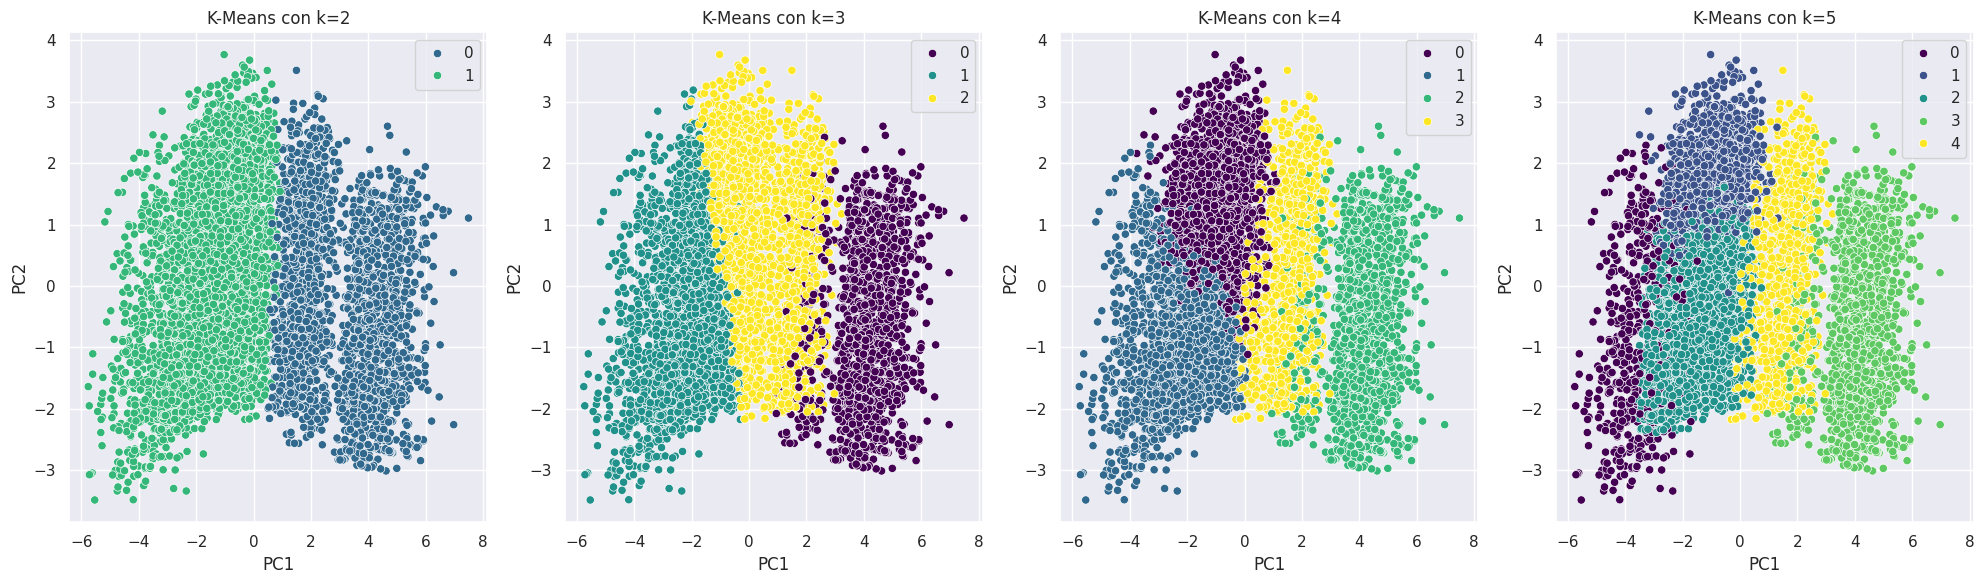

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

#  PCA para reducir a 2 dimensiones y visualizar
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])

# Comparación de K=2,3, 4 y 5
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
ks = [2,3, 4, 5]

for i, k in enumerate(ks):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)

    sns.scatterplot(x=df_pca['PC1'], y=df_pca['PC2'], hue=labels,
                    palette='viridis', ax=axes[i], legend='full')
    axes[i].set_title(f'K-Means con k={k}')

plt.tight_layout()
plt.show()

A continuación vamos a aplicar el algoritmo kMedoides.



In [ ]:
!pip install kmedoids

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 476.3/476.3 kB 8.4 MB/s eta 0:00:00


In [ ]:
from kmedoids import KMedoids

wcss = []
for i in range(1, 10):
    kmedoids_instance = KMedoids(n_clusters=i, metric='euclidean', method='pam')
    kmedoids_instance.fit(df_scaled.values)  # <-- add .values
    wcss.append(kmedoids_instance.inertia_)

wcss

[52018.6313409487,
 48484.248776213055,
 46110.063480573685,
 44738.82126189502,
 43543.57549339253,
 42534.87473495762,
 41573.44769222726,
 40693.91298926261,
 39960.19450481685]

Método del codo

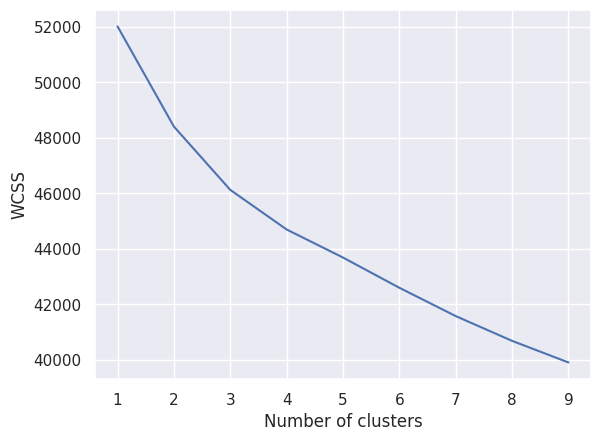

In [ ]:
plt.plot(range(1,10),wcss)
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

Observando el gráfico vamos a estudiar nuestro problema con k=2,3,4 clusters.

Dado que el dataset final posee una alta dimensionalidad, lo que imposibilita una representación gráfica directa, se aplicará PCA (Análisis de Componentes Principales) con el único fin de reducir el espacio a dos dimensiones, al igual que hicimos con K-medias.

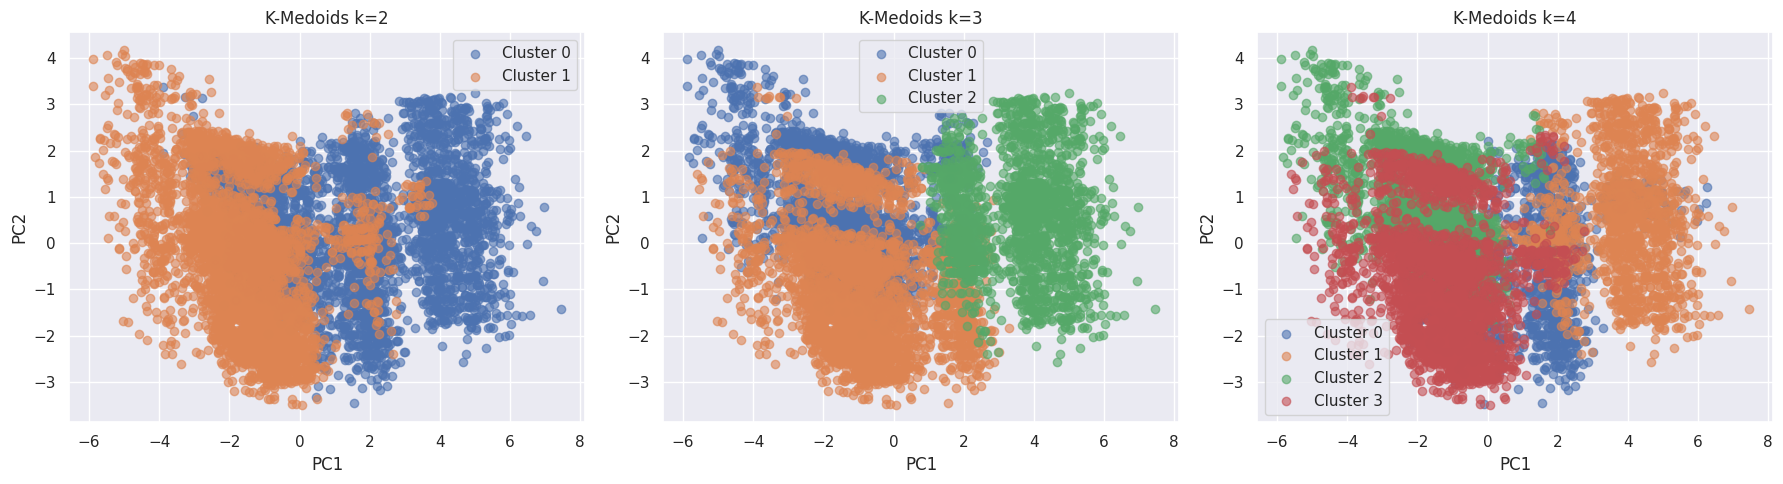

In [ ]:

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled.values)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, k in zip(axes, [2, 3, 4]):
    kmedoids_instance = KMedoids(n_clusters=k, metric='euclidean', method='pam')
    kmedoids_instance.fit(df_scaled.values)
    labels = kmedoids_instance.labels_

    for cluster in range(k):
        mask = labels == cluster
        ax.scatter(df_pca[mask, 0], df_pca[mask, 1], label=f'Cluster {cluster}', alpha=0.6)

    ax.set_title(f'K-Medoids k={k}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend()

plt.tight_layout()
plt.show()


A continuación realizaremos un análisis de los medoides

In [ ]:
from kmedoids import KMedoids

for k in [2, 3, 4]:
    kmedoids_instance = KMedoids(n_clusters=k, metric='euclidean', method='pam', random_state=42)
    kmedoids_instance.fit(df_scaled.values)

    print(f"\n{'='*60}")
    print(f"K = {k} — Tamaño de cada cluster:")
    labels = kmedoids_instance.labels_
    for c in range(k):
        print(f"  Cluster {c}: {(labels == c).sum()} pacientes")

    print(f"\nPerfil de los medoides (valores originales):")
    for i, idx in enumerate(kmedoids_instance.medoid_indices_):
        fila = df_clustering.iloc[idx]  # df_clustering: original sin dummies ni escalar
        print(f"\n  Medoide Cluster {i}:")
        print(f"    Edad:                {fila['age']}")
        print(f"    Diagnóstico:         {fila['primary_diagnosis']}")
        print(f"    Comorbilidades:      {fila['comorbidities_count']}")
        print(f"    Días hospitalizado:  {fila['length_of_stay']}")
        print(f"    Tratamiento:         {fila['treatment_type']}")
        print(f"    Medicamentos:        {fila['medications_count']}")
        print(f"    Visitas seguimiento: {fila['followup_visits_last_year']}")
        print(f"    Reingresos previos:  {fila['prev_readmissions']}")
        print(f"    Seguro:              {fila['insurance_type']}")
        print(f"    Alta a:              {fila['discharge_disposition']}")
        print(f"    Riesgo reingreso:    {fila['readmission_risk_score']}")


K = 2 — Tamaño de cada cluster:
  Cluster 0: 5878 pacientes
  Cluster 1: 2122 pacientes

Perfil de los medoides (valores originales):

  Medoide Cluster 0:
    Edad:                54
    Diagnóstico:         Diabetes
    Comorbilidades:      4
    Días hospitalizado:  8
    Tratamiento:         Medical
    Medicamentos:        7
    Visitas seguimiento: 3
    Reingresos previos:  2
    Seguro:              Private
    Alta a:              Home Health
    Riesgo reingreso:    0.71

  Medoide Cluster 1:
    Edad:                73
    Diagnóstico:         Hypertension
    Comorbilidades:      6
    Días hospitalizado:  7
    Tratamiento:         Medical
    Medicamentos:        10
    Visitas seguimiento: 6
    Reingresos previos:  2
    Seguro:              Medicare
    Alta a:              Skilled Nursing
    Riesgo reingreso:    0.97

K = 3 — Tamaño de cada cluster:
  Cluster 0: 3080 pacientes
  Cluster 1: 1753 pacientes
  Cluster 2: 3167 pacientes

Perfil de los medoides (valores o

Al final, usar este nuevo método nos confirma lo que ya sospechábamos.
Una vez más el k=3 es el más óptimo, los motivos son los mismos que ocurrían en el K-medias. Definimos a partir de este resultado los siguientes clústeres:

- Cluster 0 — Paciente adulto de riesgo moderado

- Cluster 1 — Paciente anciano de alto riesgo

- Cluster 2 — Paciente más joven, riesgo medio-alto







Por último vamos a aplicar el clustering Jerárquico.

Usamos el dendograma para encontrar el número óptimo de clústeres (Muestra de 2000 pacientes)

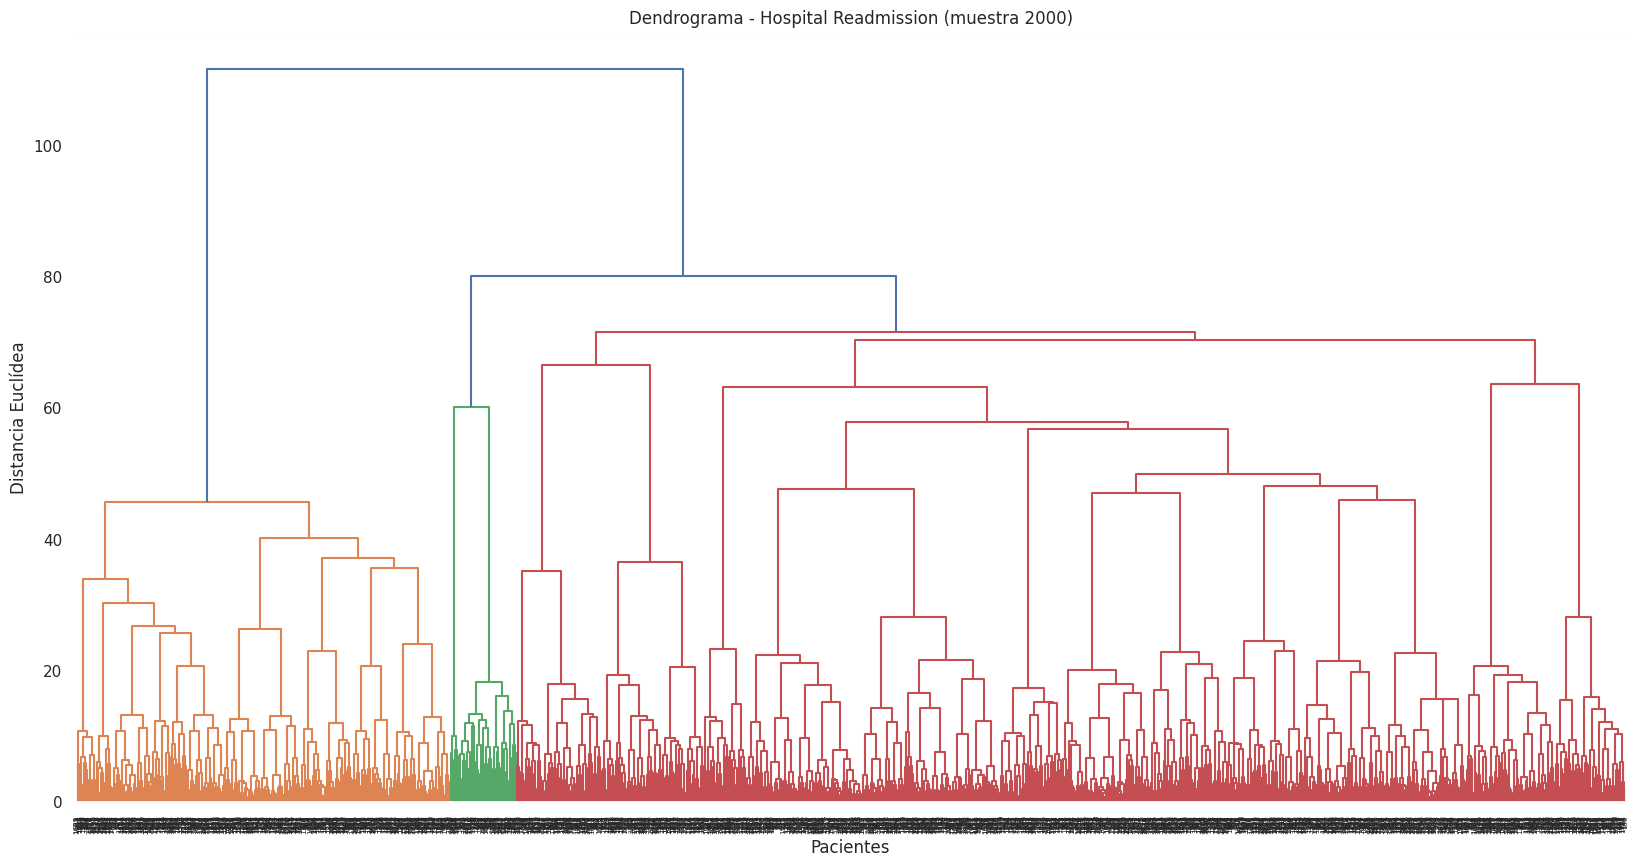

In [ ]:
import numpy as np
import scipy.cluster.hierarchy as sch

np.random.seed(42)
# Muestra para visualizar mejor
sample_idx = np.random.choice(len(df_scaled), size=2000, replace=False)
data_sample = df_scaled.values[sample_idx]

plt.figure(figsize=(20, 10))
dendrogram = sch.dendrogram(sch.linkage(data_sample, method='ward'))

plt.title('Dendrograma - Hospital Readmission (muestra 2000)')
plt.xlabel('Pacientes')
plt.ylabel('Distancia Euclídea')
plt.show()

Cortamos apróximadamente a una altura de 60-75 y encontramos los 3 clústeres

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster




np.random.seed(42)
sample_idx = np.random.choice(len(df_scaled), size=2000, replace=False)
data_sample = df_scaled.values[sample_idx]

# Clustering jerárquico k=3
linkage_matrix = sch.linkage(data_sample, method='ward')
cluster_labels = fcluster(linkage_matrix, t=3, criterion='maxclust')

# Valores originales + etiquetas
df_original_sample = df_final.iloc[sample_idx].copy()
df_original_sample['cluster'] = cluster_labels

# ── Numéricas ────────────────────────────────────────────────────────────────
numeric_cols = ['age', 'comorbidities_count', 'length_of_stay',
                'medications_count', 'followup_visits_last_year',
                'prev_readmissions', 'readmission_risk_score']

print("=== VARIABLES NUMÉRICAS (media) ===")
print(df_original_sample.groupby('cluster')[numeric_cols].mean().round(2).T.to_string())

# ── Categóricas ──────────────────────────────────────────────────────────────
dummy_cols = [c for c in df_original_sample.columns
              if c.startswith(('gender_', 'primary_diagnosis_',
                               'treatment_type_', 'insurance_type_',
                               'discharge_disposition_'))]

print("\n=== VARIABLES CATEGÓRICAS (%) ===")
print((df_original_sample.groupby('cluster')[dummy_cols].mean() * 100).round(1).T.to_string())


=== VARIABLES NUMÉRICAS (media) ===
cluster                        1      2      3
age                        75.17  28.56  52.95
comorbidities_count         5.74   1.85   3.97
length_of_stay              8.20   6.54   7.83
medications_count           9.59   3.71   6.98
followup_visits_last_year   5.29   1.86   3.18
prev_readmissions           2.27   0.42   1.38
readmission_risk_score      0.96   0.33   0.74

=== VARIABLES CATEGÓRICAS (%) ===
cluster                                   1     2     3
gender_Female                          53.1  50.6  53.7
gender_Male                            46.9  49.4  46.3
primary_diagnosis_Appendicitis          0.0   7.1   9.2
primary_diagnosis_COPD                 16.9  12.9   8.5
primary_diagnosis_Diabetes             24.2  17.6  15.4
primary_diagnosis_Fracture              0.0   4.7   7.7
primary_diagnosis_Heart Failure         0.0   1.2   6.4
primary_diagnosis_Hypertension         23.8  23.5  13.8
primary_diagnosis_Influenza             0.0   0.0

Los tres algoritmos de clustering aplicados —K-Means, clustering jerárquico y K-Medoides— permiten identificar agrupaciones coherentes dentro de la población hospitalaria analizada, aunque con diferencias notables en sus resultados.
K-Means y el clustering jerárquico obtienen una estructura similar de tres perfiles bien diferenciados. El primero corresponde a pacientes mayores de alto riesgo, elevado número de comorbilidades, alta carga farmacológica y un riesgo de reingreso muy alto. El segundo agrupa a pacientes jóvenes de bajo riesgo,pocas comorbilidades, escasos reingresos previos y un riesgo de reingreso bajo, que en su mayoría reciben el alta a domicilio. El tercero representa un perfil intermedio de mediana edad, con valores moderados en todas las variables clínicas y un riesgo de reingreso medio.
K-Medoides, sin embargo, produce una segmentación distinta: el grupo de bajo riesgo desaparece como categoría independiente, quedando absorbido por los otros dos clusters.
